In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import chisquare

Question 1:

The Capital Asset Pricing Model (CAPM) is a financial model that assumes returns on a portfolio are normally distributed.  Suppose a portfolio has an average annual return of 14.7% (i.e., an average gain on 14.7%) with a standard deviation of 33%.  A return of 0% means the value of the portfolio doesn't change, a negative return means that the portfolio loses money, and a positive return means that the portfolio gains money. Determine the following:

1. What percentage of years does this portfolio lose money, (i.e. have a return less than 0%)?
2. What is the cutoff for the highest 15% of annual returns with this portfolio?


Answer: 48.9% 

- Portfolio loses money about 32.8% of the years
- Cutoff for the highest 15% of returns is about 48.9% 


Question 2

Past experience indicates that because of low morale, a company loses 20 hours a year per employee due to lateness and absenteeism.  Assume that the standard deviation of the population is 6 and normally distributed.

The HR department implemented a new rewards system to increase employee morale, and after a few months it collected a random sample of 20 employees and the annualized absenteeism was 14.

Could you confirm that the new rewards system was effective with a 90% confidence?
An HR subject matter expert would be very happy if the program could reduce absenteeism by 20% (i.e. to 16 hours).  Given the current sampling parameters (sample size of 20 and std. dev. of population is 6), what is the probability that the new rewards system reduced absenteeism to 16 hours and you miss it? (significance level 0.10)


1. Could you confirm the rewards system was effective with 90% confidence?
Yes. The z-statistic is about -4.47, so we reject the null hypothesis and conclude the program reduced absenteeism.

2. Probability that the true mean is 16 hours and you miss it: 0.0446 or 4.46%

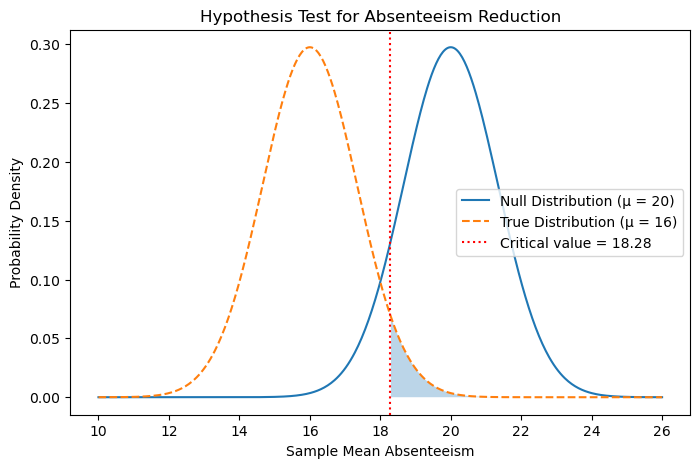

In [8]:
# Given values
mu_null = 20
mu_true = 16
sigma = 6
n = 20
alpha = 0.10

# Standard error
SE = sigma / np.sqrt(n)

# Critical z value
z_crit = norm.ppf(alpha)

# Critical sample mean cutoff
x_crit = mu_null + z_crit * SE

# x values
x = np.linspace(10, 26, 500)

# Distributions
y_null = norm.pdf(x, mu_null, SE)
y_true = norm.pdf(x, mu_true, SE)

plt.figure(figsize=(8,5))

# Plot distributions
plt.plot(x, y_null, label="Null Distribution (μ = 20)")
plt.plot(x, y_true, label="True Distribution (μ = 16)", linestyle="--")

# Critical line
plt.axvline(x_crit, color="red", linestyle=":", label=f"Critical value = {x_crit:.2f}")

# Shade Type II error
plt.fill_between(x, y_true, where=(x >= x_crit), alpha=0.3)

plt.title("Hypothesis Test for Absenteeism Reduction")
plt.xlabel("Sample Mean Absenteeism")
plt.ylabel("Probability Density")
plt.legend()

plt.show()

Question 3:

Given the information in section 6.3.5, write python code for the following.
- Calculate the expected valaues based on the geometric distribution with a probability of 54.5%
- Compare the expected vs. the observed values from the textbook using the Chi-Square distribution
- Reach a conclusion

Chi-square statistic: 4.610747780774838
p-value: 0.5946142546545656


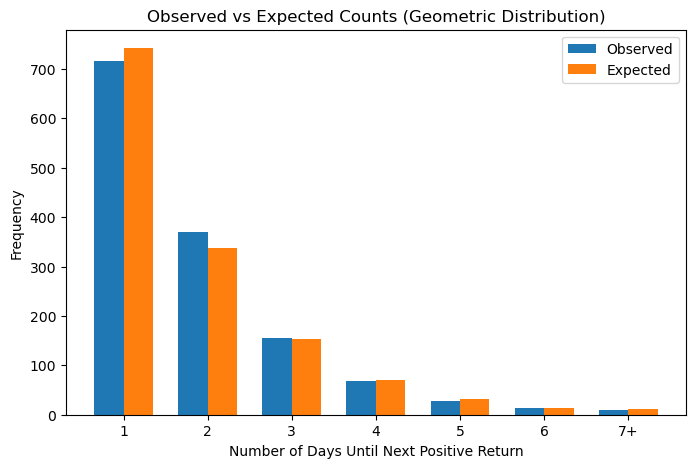

In [9]:
# Observed counts from OpenIntro example
observed = np.array([717, 369, 155, 69, 28, 14, 10])

# probability for geometric distribution
p = 0.545
n = 1362

# Expected probabilities
probs = np.array([
    p,
    (1-p)*p,
    (1-p)**2 * p,
    (1-p)**3 * p,
    (1-p)**4 * p,
    (1-p)**5 * p,
    (1-p)**6
])

# Expected counts
expected = n * probs

# Chi-square test
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

# Plot
x = np.arange(len(observed))
labels = ["1","2","3","4","5","6","7+"]

width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, observed, width, label="Observed")
plt.bar(x + width/2, expected, width, label="Expected")

plt.xlabel("Number of Days Until Next Positive Return")
plt.ylabel("Frequency")
plt.title("Observed vs Expected Counts (Geometric Distribution)")
plt.xticks(x, labels)
plt.legend()

plt.show()

In [10]:
# Observed counts from OpenIntro section 6.3.5
observed = np.array([717, 369, 155, 69, 28, 14, 10])

# Parameters from the textbook example
p = 0.545
n = 1362

# Expected probabilities for a geometric distribution
# Bins: 1, 2, 3, 4, 5, 6, 7+
probs = np.array([
    p,                         # P(X=1)
    (1-p) * p,                 # P(X=2)
    (1-p)**2 * p,              # P(X=3)
    (1-p)**3 * p,              # P(X=4)
    (1-p)**4 * p,              # P(X=5)
    (1-p)**5 * p,              # P(X=6)
    (1-p)**6                   # P(X>=7)
])

# Expected counts
expected = n * probs

print("Expected counts:")
print(expected)

# Chi-square goodness-of-fit test
chi2_stat = np.sum((observed - expected)**2 / expected)
df = len(observed) - 1
p_value = 1 - chi2.cdf(chi2_stat, df)

print("\nChi-square statistic:", chi2_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

# You can also verify with scipy.stats.chisquare
chi2_stat2, p_value2 = chisquare(f_obs=observed, f_exp=expected)
print("\nScipy check:")
print("Chi-square statistic:", chi2_stat2)
print("p-value:", p_value2)

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject H0.")
    print("The data do NOT fit the geometric distribution well.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("The data are consistent with the geometric distribution.")

Expected counts:
[742.29       337.74195    153.67258725  69.9210272   31.81406738
  14.47540066  12.08496752]

Chi-square statistic: 4.610747780774838
Degrees of freedom: 6
p-value: 0.5946142546545656

Scipy check:
Chi-square statistic: 4.610747780774838
p-value: 0.5946142546545656

Conclusion: Fail to reject H0.
The data are consistent with the geometric distribution.
